In [34]:
library(tidyverse)
library(dplyr)
library(ggplot2)
library(vegan)
library(compositions)
library(ecodist)
library(cowplot)

# File sorting============================================================================================================

In [35]:
# Read taxa data
taxa_tab <- read.table("/ceph/projects/010_SweMaMi/bm.nowak/data/tp1_taxa_fp_sp__50_250822.tsv", header = TRUE, sep ="\t", check.names = FALSE, quote='"') 
dim(taxa_tab)
head(taxa_tab)

[1] 984  50

,100000115046,100000133514,100000138427,100000416914,100000416341,100000417300,100000141564,100000112861,100000116982,100000117590,⋯,100000404683,100000410189,100000180006,100000410554,100000422410,100000424421,100000167687,100000422946,100000165058,100000419175
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Coprococcus eutactus,1.92768,0.15521,0.05160,0.02486,6.62230,0.30236,2.25139,0.00000,0.00000,0.42317,⋯,0.16779,2.72513,0.00000,0.93544,0.00000,4.42402,0.00000,4.46554,0.00000,0.00000
Faecalibacterium prausnitzii,3.20883,4.32581,4.53698,3.39437,3.26358,7.13674,4.51069,7.70578,4.33970,0.19672,⋯,2.84157,3.24886,5.24076,1.91233,6.89058,7.44669,2.90277,6.99612,6.78398,7.72660
Ruminococcus bromii,12.75072,0.84583,5.68254,2.92580,0.00044,4.13723,5.12663,4.96465,1.35757,8.26843,⋯,4.74826,12.33869,7.39686,0.00842,0.00135,1.89198,7.79235,0.00361,13.89218,0.00000
Ruminococcus bicirculans,0.64417,0.04445,2.55341,0.11893,0.09988,1.25623,1.32888,0.00064,4.66429,0.70478,⋯,0.19760,0.28484,0.00000,0.01427,0.10956,1.09689,0.10850,3.50633,0.00000,0.00000
Eubacterium rectale,0.95028,1.20350,5.57078,0.13382,2.26475,3.46031,0.59886,0.63884,2.51539,0.09724,⋯,0.12479,3.22173,1.25968,0.10241,4.25136,1.03758,21.90512,0.20310,2.13466,8.66076
Phocaeicola vulgatus,1.31137,1.54361,0.37413,0.28747,0.96566,2.37364,2.17415,3.13447,0.00000,2.93263,⋯,2.52242,2.21001,5.07246,3.08527,2.57127,1.68231,0.00026,3.65610,4.75778,4.36198


In [36]:
colnames(taxa_tab)

[1] "100000115046" "100000133514" "100000138427" "100000416914" "100000416341"
 [6] "100000417300" "100000141564" "100000112861" "100000116982" "100000117590"
[11] "100000126486" "100000114162" "100000110713" "100000108109" "100000103241"
[16] "100000101469" "100000415924" "100000417676" "100000402412" "100000401705"
[21] "100000401859" "100000424865" "100000193464" "100000157404" "100000128343"
[26] "100000101674" "100000101155" "100000102589" "100000114025" "100000158999"
[31] "100000101841" "100000148624" "100000102794" "100000129906" "100000136621"
[36] "100000124499" "100000419489" "100000429136" "100000417447" "100000401965"
[41] "100000404683" "100000410189" "100000180006" "100000410554" "100000422410"
[46] "100000424421" "100000167687" "100000422946" "100000165058" "100000419175"

In [37]:
taxa_tab[, 1]

[1]  1.92768  3.20883 12.75072  0.64417  0.95028  1.31137  1.09072  0.27629
  [9]  2.24122  0.00000  0.00000  0.00000  2.52593  1.75332  0.93406  1.51821
 [17]  0.57943  1.87246  0.47620  0.53308  0.00000  0.01418  0.77935  1.93256
 [25]  0.09474  0.66964  1.00237  0.58479  1.12836  0.44795  0.07149  0.60658
 [33]  0.24541  0.36206  0.00000  0.40623  0.44727  0.13883  0.00000  0.00000
 [41]  0.30232  0.00823  0.00000  3.52266  0.26468  0.46706  0.15246  0.53333
 [49]  0.16055  0.06101  0.10488  0.01344  0.18417  0.24924  0.44037  0.00000
 [57]  0.09464  0.00000  0.00000  0.12919  0.25350  0.05122  0.01220  0.17460
 [65]  0.33826  0.63592  0.17338  0.19604  0.11116  0.09649  0.00000  0.00000
 [73]  0.55267  0.91567  0.90100  0.14455  0.27360  0.03501  0.08576  0.00000
 [81]  0.00843  0.47442  0.00659  0.22679  0.24442  0.17284  0.00785  0.00764
 [89]  0.00000  0.00000  0.04528  0.11533  0.70758  0.03964  0.00000  0.10336
 [97]  0.20686  0.05096  0.68265  0.87287  0.06382  0.55525  0.06119  0.00000
[105]  0.01462  0.00000  0.00000  0.20754  0.39751  0.11420  0.00203  0.01281
[113]  0.39001  0.19615  0.00210  0.05501  0.00000  0.00000  0.00000  0.00000
[121]  0.01828  0.09674  0.01924  0.05677  0.45188  0.22052  0.04047  0.06329
[129]  0.01164  0.00000  0.00151  1.03222  0.00000  0.11058  0.00000  0.27612
[137]  0.00000  0.00980  0.00867  0.00000  0.00000  0.02419  0.09819  0.00000
[145]  0.02649  0.00000  0.13850  0.00000  0.11731  0.00760  0.00433  0.53331
[153]  0.02778  0.01947  0.00000  0.13499  0.01156  0.32244  0.00000  0.03771
[161]  0.03226  0.00000  0.00000  0.00000  0.58217  0.01691  0.00000  0.00000
[169]  0.02987  0.02696  0.03105  0.00517  0.02339  0.00000  0.00320  0.01116
[177]  0.05235  0.00000  0.41285  0.02262  0.13884  0.00418  0.00000  0.00321
[185]  0.00000  1.26094  0.07219  0.00427  0.35658  0.06629  0.00000  0.08985
[193]  0.03710  0.02060  0.50113  0.60669  0.02181  0.00000  0.04530  0.06454
[201]  0.00417  0.00000  0.00000  0.04188  0.03139  0.00665  0.00000  0.00000
[209]  0.04176  0.00000  0.01470  0.00000  0.00920  0.04365  0.03356  0.00000
[217]  0.00137  0.00112  0.03669  0.00000  0.01631  0.06524  0.02436  0.00646
[225]  0.00000  0.06601  0.21153  0.11765  0.00299  0.00000  0.00062  0.00332
[233]  0.00000  2.53829  0.19914  0.00023  0.01867  0.00000  0.00256  0.00784
[241]  0.00000  0.00598  0.00343  0.00000  0.00602  0.00000  0.00246  0.00000
[249]  0.00034  0.00065  0.00000  0.00032  0.01186  0.00000  0.03982  0.02831
[257]  0.00404  0.00348  0.00000  0.00261  0.01073  0.00000  0.00000  0.00000
[265]  0.00000  0.00000  0.01266  0.00684  0.00025  0.37091  0.00000  0.00185
[273]  0.01057  0.22110  0.00509  0.00000  0.00000  0.03213  0.02145  0.00310
[281]  0.00000  0.00000  0.02505  0.03966  0.00000  0.00000  0.00000  0.00693
[289]  0.00000  0.00000  0.55409  0.00000  0.00000  0.00000  0.00220  0.00104
[297]  0.00000  0.00000  0.00478  0.00180  0.00122  0.00062  0.00620  0.00000
[305]  0.00000  0.00224  0.00000  0.00000  0.00128  0.00475  0.00000  0.00533
[313]  0.00306  0.00112  0.00000  0.00000  0.47524  0.00000  0.00879  0.08567
[321]  0.00166  0.00000  0.00000  0.00074  0.00222  0.00000  0.00000  0.00275
[329]  0.00000  0.04748  0.00022  0.00000  0.62936  0.00000  0.00014  0.00358
[337]  0.00000  0.00000  0.00000  0.00000  0.00000  0.00149  0.03199  0.26986
[345]  0.00000  0.00000  0.00000  0.00000  0.00161  0.00000  0.00000  0.00235
[353]  0.00000  0.00000  0.00387  0.00233  0.00296  0.00168  0.00000  0.00000
[361]  0.00000  0.00000  0.00000  0.00000  0.00000  0.00000  0.00000  0.00000
[369]  0.00694  0.00000  0.00080  0.00000  0.00121  0.00000  0.00000  0.00000
[377]  0.00000  0.00000  0.00194  0.00082  0.00089  0.00000  0.00000  0.00662
[385]  0.00000  0.00000  0.00000  0.00402  0.00000  0.00000  0.00224  0.00000
[393]  0.00655  0.00000  0.00000  0.00000  0.01078  0.00000  0.00000  0.00000
[401]  0.00000  0.00000  0.00000  0.00000  0.00000  0.00080  0.00000  0.00000
[409]  0.00000  0.00000 

In [38]:
tail(taxa_tab)

,100000115046,100000133514,100000138427,100000416914,100000416341,100000417300,100000141564,100000112861,100000116982,100000117590,⋯,100000404683,100000410189,100000180006,100000410554,100000422410,100000424421,100000167687,100000422946,100000165058,100000419175
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
GGB4723 SGB6540,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,⋯,0.0000,0.00000,0.00000,0.00000,0.00000,0.00000,0.0000,0.00000,0.00000,0.00000
GGB28474 SGB41058,0.00000,0.00000,0.00000,0.00532,0.00000,0.00573,0.00011,0.00000,0.00000,0.00000,⋯,0.0000,0.00000,0.00000,0.00000,0.00000,0.00000,0.0000,0.00000,0.00000,0.00000
GGB6123 SGB8767,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,⋯,0.0000,0.00000,0.00000,0.00000,0.00000,0.00000,0.0000,0.00000,0.00000,0.00000
GGB9060 SGB13977,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,⋯,0.0000,0.00000,0.00000,0.00000,0.00000,0.00000,0.0000,0.09733,0.00000,0.00000
Oscillospiraceae unclassified_SGB15252,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,⋯,0.0000,0.00000,0.00000,0.00000,0.00000,0.00000,0.0000,0.00000,0.00000,0.00000
Other_taxa,2.36071,4.74968,2.96481,0.07106,2.25795,7.41692,8.73482,5.03367,2.60627,0.67493,⋯,3.2181,3.86036,2.55824,0.88144,4.63333,0.77398,2.8099,1.43148,0.22941,0.20306


In [39]:
colSums(taxa_tab)

100000115046 100000133514 100000138427 100000416914 100000416341 100000417300 
         100          100          100          100          100          100 
100000141564 100000112861 100000116982 100000117590 100000126486 100000114162 
         100          100          100          100          100          100 
100000110713 100000108109 100000103241 100000101469 100000415924 100000417676 
         100          100          100          100          100          100 
100000402412 100000401705 100000401859 100000424865 100000193464 100000157404 
         100          100          100          100          100          100 
100000128343 100000101674 100000101155 100000102589 100000114025 100000158999 
         100          100          100          100          100          100 
100000101841 100000148624 100000102794 100000129906 100000136621 100000124499 
         100          100          100          100          100          100 
100000419489 100000429136 100000417447 100000401965 100000404683 100000410189 
         100          100          100          100          100          100 
100000180006 100000410554 100000422410 100000424421 100000167687 100000422946 
         100          100          100          100          100          100 
100000165058 100000419175 
         100          100

In [40]:
taxa <- as.data.frame(t(taxa_tab))
class(taxa)
head(taxa)

[1] "data.frame"

,Coprococcus eutactus,Faecalibacterium prausnitzii,Ruminococcus bromii,Ruminococcus bicirculans,Eubacterium rectale,Phocaeicola vulgatus,Candidatus Cibionibacter_quicibialis,Lachnospira pectinoschiza,Clostridium sp_AF34_10BH,Catenibacterium SGB4425,⋯,GGB3111 SGB4123,Staphylococcus aureus,GGB9522 SGB98319,Candidatus Alangreenwoodia_gallinarii,GGB4723 SGB6540,GGB28474 SGB41058,GGB6123 SGB8767,GGB9060 SGB13977,Oscillospiraceae unclassified_SGB15252,Other_taxa
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
100000115046,1.92768,3.20883,12.75072,0.64417,0.95028,1.31137,1.09072,0.27629,2.24122,0.00000,⋯,0,0,0.00000,0,0,0.00000,0,0,0,2.36071
100000133514,0.15521,4.32581,0.84583,0.04445,1.20350,1.54361,4.83623,0.00000,0.05056,0.00000,⋯,0,0,0.00000,0,0,0.00000,0,0,0,4.74968
100000138427,0.05160,4.53698,5.68254,2.55341,5.57078,0.37413,0.25773,0.37810,0.00317,0.00000,⋯,0,0,0.00000,0,0,0.00000,0,0,0,2.96481
100000416914,0.02486,3.39437,2.92580,0.11893,0.13382,0.28747,7.79970,0.08632,0.03749,0.13595,⋯,0,0,0.01279,0,0,0.00532,0,0,0,0.07106
100000416341,6.62230,3.26358,0.00044,0.09988,2.26475,0.96566,0.68823,0.03252,0.17014,0.00000,⋯,0,0,0.00766,0,0,0.00000,0,0,0,2.25795
100000417300,0.30236,7.13674,4.13723,1.25623,3.46031,2.37364,1.02179,0.00095,3.69770,1.54096,⋯,0,0,0.00000,0,0,0.00573,0,0,0,7.41692


In [41]:
# Read metadata
combined_meta_tp1 <- read.csv("/ceph/projects/010_SweMaMi/bm.nowak/filtered_data/feacal/tp1_nulliparous/2025-08-01_combined_fp_sp_tp1.csv", header = TRUE, row.names = 1)
head(combined_meta_tp1)
dim(combined_meta_tp1)

,Studienummer,Correct_PN,Prev_RPL,Prev_IUFD,Prev_miscarriage_numb,Q1_Datum,Q1_Personnummer,Avbruten_graviditet,age_checked,Age_groups,⋯,missfall.IUFD_week,IUFD,missfall,missfall.IUFD_comments,Gest_w_combined,deliv_start_combined,Type_of_PTB,s_PTB,preeclampsia_epi_analysis,Group
,<chr>,<lgl>,<int>,<int>,<int>,<chr>,<chr>,<int>,<int>,<int>,⋯,<lgl>,<lgl>,<lgl>,<lgl>,<int>,<chr>,<chr>,<int>,<int>,<chr>
5367,S194e21b,NA,0,0,0,2018-11-16,P159f9c8,0,36,4,⋯,NA,NA,NA,NA,41,Spontaneous,NA,NA,0,First pregnancy
5297,S1a267fa,NA,0,0,0,2019-05-23,P1a267fa,0,32,3,⋯,NA,NA,NA,NA,38,Spontaneous,NA,NA,0,First pregnancy
5208,Sa8397fa,NA,0,0,0,2018-03-14,P1ef420d,0,27,2,⋯,NA,NA,NA,NA,28,Spontaneous,very_w28_31,1,0,First pregnancy
5301,S1f862a6,NA,0,0,0,2018-03-07,P1f862a6,0,32,3,⋯,NA,NA,NA,NA,31,Spontaneous,very_w28_31,1,0,First pregnancy
5285,S3c0f6ee,NA,0,0,0,2019-03-25,P3c0f6ee,0,31,3,⋯,NA,NA,NA,NA,38,Spontaneous,NA,NA,0,First pregnancy
5275,S2b86cc0,NA,0,0,0,2019-05-29,P3cac7b0,0,31,3,⋯,NA,NA,NA,NA,39,Spontaneous,NA,NA,0,First pregnancy


[1]  50 566

In [42]:
# Select variables from metadata
variables_tp1 <- combined_meta_tp1 |> 
    select (Group, Studienummer, Q1_Personnummer, age_checked, Age_groups, excess_weight, Weight_before_C, BMI_prior, kit1.faecal_sample.barcode, 
            Primipara, Q1_Smoking_checked, Q1_X64_Alcohol_during_pregnancy, Q1_X43.Antibiotics_last_3_months, high_stress_Q1, BMI_now_3_groups) 

In [43]:
dim(variables_tp1)
head(variables_tp1)

[1] 50 15

,Group,Studienummer,Q1_Personnummer,age_checked,Age_groups,excess_weight,Weight_before_C,BMI_prior,kit1.faecal_sample.barcode,Primipara,Q1_Smoking_checked,Q1_X64_Alcohol_during_pregnancy,Q1_X43.Antibiotics_last_3_months,high_stress_Q1,BMI_now_3_groups
,<chr>,<chr>,<chr>,<int>,<int>,<chr>,<int>,<int>,<dbl>,<int>,<chr>,<int>,<int>,<int>,<chr>
5367,First pregnancy,S194e21b,P159f9c8,36,4,Yes,60,21,100000128343,1,"Nej, jag har aldrig rökt",0,0,0,25
5297,First pregnancy,S1a267fa,P1a267fa,32,3,No,55,21,100000158999,1,Rökt tidigare,0,0,0,18.5-25 Normal weight
5208,First pregnancy,Sa8397fa,P1ef420d,27,2,No,67,25,100000101469,1,Rökt tidigare,0,0,0,25
5301,First pregnancy,S1f862a6,P1f862a6,32,3,Yes,67,25,100000103241,1,Rökt tidigare,0,0,0,> 25 Overweight
5285,First pregnancy,S3c0f6ee,P3c0f6ee,31,3,No,97,36,100000141564,1,"Nej, jag har aldrig rökt",0,1,1,> 25 Overweight
5275,First pregnancy,S2b86cc0,P3cac7b0,31,3,No,56,21,100000157404,1,Rökt tidigare,0,0,1,18.5-25 Normal weight


In [44]:
variables_tp1$Group <- as.factor(variables_tp1$Group)
variables_tp1$kit1.faecal_sample.barcode <- as.character(variables_tp1$kit1.faecal_sample.barcode)
variables_tp1$excess_weight <- as.factor(variables_tp1$excess_weight)
variables_tp1$Q1_X64_Alcohol_during_pregnancy <- as.factor(variables_tp1$Q1_X64_Alcohol_during_pregnancy)
variables_tp1$Q1_X43.Antibiotics_last_3_months <- as.factor(variables_tp1$Q1_X43.Antibiotics_last_3_months)
variables_tp1$high_stress_Q1 <- as.factor(variables_tp1$high_stress_Q1)

In [45]:
head(variables_tp1)

,Group,Studienummer,Q1_Personnummer,age_checked,Age_groups,excess_weight,Weight_before_C,BMI_prior,kit1.faecal_sample.barcode,Primipara,Q1_Smoking_checked,Q1_X64_Alcohol_during_pregnancy,Q1_X43.Antibiotics_last_3_months,high_stress_Q1,BMI_now_3_groups
,<fct>,<chr>,<chr>,<int>,<int>,<fct>,<int>,<int>,<chr>,<int>,<chr>,<fct>,<fct>,<fct>,<chr>
5367,First pregnancy,S194e21b,P159f9c8,36,4,Yes,60,21,100000128343,1,"Nej, jag har aldrig rökt",0,0,0,25
5297,First pregnancy,S1a267fa,P1a267fa,32,3,No,55,21,100000158999,1,Rökt tidigare,0,0,0,18.5-25 Normal weight
5208,First pregnancy,Sa8397fa,P1ef420d,27,2,No,67,25,100000101469,1,Rökt tidigare,0,0,0,25
5301,First pregnancy,S1f862a6,P1f862a6,32,3,Yes,67,25,100000103241,1,Rökt tidigare,0,0,0,> 25 Overweight
5285,First pregnancy,S3c0f6ee,P3c0f6ee,31,3,No,97,36,100000141564,1,"Nej, jag har aldrig rökt",0,1,1,> 25 Overweight
5275,First pregnancy,S2b86cc0,P3cac7b0,31,3,No,56,21,100000157404,1,Rökt tidigare,0,0,1,18.5-25 Normal weight


In [46]:
# Convert Q1_Smoking_ to categories 
smoking_category <- ifelse(variables_tp1$Q1_Smoking_checked == "Nej, jag har aldrig rökt", 0, 
                           ifelse(variables_tp1$Q1_Smoking_checked == "Rökt tidigare", 0,
                              ifelse(variables_tp1$Q1_Smoking_checked == "Feströkare", 1, NA)))

In [47]:
smoking_category

[1] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
[39] 0 0 0 0 0 0 0 0 0 0 0 0

In [48]:
# Replace column with smoking category
variables_tp1$Q1_Smoking_checked <- as.factor(smoking_category)
variables_tp1$Q1_Smoking_checked
head(variables_tp1)

[1] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
[39] 0 0 0 0 0 0 0 0 0 0 0 0
Levels: 0 1

,Group,Studienummer,Q1_Personnummer,age_checked,Age_groups,excess_weight,Weight_before_C,BMI_prior,kit1.faecal_sample.barcode,Primipara,Q1_Smoking_checked,Q1_X64_Alcohol_during_pregnancy,Q1_X43.Antibiotics_last_3_months,high_stress_Q1,BMI_now_3_groups
,<fct>,<chr>,<chr>,<int>,<int>,<fct>,<int>,<int>,<chr>,<int>,<fct>,<fct>,<fct>,<fct>,<chr>
5367,First pregnancy,S194e21b,P159f9c8,36,4,Yes,60,21,100000128343,1,0,0,0,0,25
5297,First pregnancy,S1a267fa,P1a267fa,32,3,No,55,21,100000158999,1,0,0,0,0,18.5-25 Normal weight
5208,First pregnancy,Sa8397fa,P1ef420d,27,2,No,67,25,100000101469,1,0,0,0,0,25
5301,First pregnancy,S1f862a6,P1f862a6,32,3,Yes,67,25,100000103241,1,0,0,0,0,> 25 Overweight
5285,First pregnancy,S3c0f6ee,P3c0f6ee,31,3,No,97,36,100000141564,1,0,0,1,1,> 25 Overweight
5275,First pregnancy,S2b86cc0,P3cac7b0,31,3,No,56,21,100000157404,1,0,0,0,1,18.5-25 Normal weight


In [49]:
# Group bmi groups
bmi_levels <- c("< 18.5 Underweight", "18.5-25 Normal weight", "> 25 Overweight")
bmi_levels
variables_tp1$BMI_now_3_groups <- factor(variables_tp1$BMI_now_3_groups, levels = bmi_levels)
class(variables_tp1$BMI_now_3_groups)

[1] "< 18.5 Underweight"    "18.5-25 Normal weight" "> 25 Overweight"

[1] "factor"

In [50]:
head(variables_tp1)

,Group,Studienummer,Q1_Personnummer,age_checked,Age_groups,excess_weight,Weight_before_C,BMI_prior,kit1.faecal_sample.barcode,Primipara,Q1_Smoking_checked,Q1_X64_Alcohol_during_pregnancy,Q1_X43.Antibiotics_last_3_months,high_stress_Q1,BMI_now_3_groups
,<fct>,<chr>,<chr>,<int>,<int>,<fct>,<int>,<int>,<chr>,<int>,<fct>,<fct>,<fct>,<fct>,<fct>
5367,First pregnancy,S194e21b,P159f9c8,36,4,Yes,60,21,100000128343,1,0,0,0,0,NA
5297,First pregnancy,S1a267fa,P1a267fa,32,3,No,55,21,100000158999,1,0,0,0,0,18.5-25 Normal weight
5208,First pregnancy,Sa8397fa,P1ef420d,27,2,No,67,25,100000101469,1,0,0,0,0,NA
5301,First pregnancy,S1f862a6,P1f862a6,32,3,Yes,67,25,100000103241,1,0,0,0,0,> 25 Overweight
5285,First pregnancy,S3c0f6ee,P3c0f6ee,31,3,No,97,36,100000141564,1,0,0,1,1,> 25 Overweight
5275,First pregnancy,S2b86cc0,P3cac7b0,31,3,No,56,21,100000157404,1,0,0,0,1,18.5-25 Normal weight


In [51]:
# Create a table with relevant variables
adonis_tab <- variables_tp1 |> rename(Studynumber = Studienummer, Personalnumber = Q1_Personnummer, Age = age_checked, Sample_ID = kit1.faecal_sample.barcode, 
                                      Smoking = Q1_Smoking_checked, Alcohol = Q1_X64_Alcohol_during_pregnancy, Antibiotics = Q1_X43.Antibiotics_last_3_months, 
                                      High_stress =  high_stress_Q1, BMI_groups = BMI_now_3_groups)
head(adonis_tab)

,Group,Studynumber,Personalnumber,Age,Age_groups,excess_weight,Weight_before_C,BMI_prior,Sample_ID,Primipara,Smoking,Alcohol,Antibiotics,High_stress,BMI_groups
,<fct>,<chr>,<chr>,<int>,<int>,<fct>,<int>,<int>,<chr>,<int>,<fct>,<fct>,<fct>,<fct>,<fct>
5367,First pregnancy,S194e21b,P159f9c8,36,4,Yes,60,21,100000128343,1,0,0,0,0,NA
5297,First pregnancy,S1a267fa,P1a267fa,32,3,No,55,21,100000158999,1,0,0,0,0,18.5-25 Normal weight
5208,First pregnancy,Sa8397fa,P1ef420d,27,2,No,67,25,100000101469,1,0,0,0,0,NA
5301,First pregnancy,S1f862a6,P1f862a6,32,3,Yes,67,25,100000103241,1,0,0,0,0,> 25 Overweight
5285,First pregnancy,S3c0f6ee,P3c0f6ee,31,3,No,97,36,100000141564,1,0,0,1,1,> 25 Overweight
5275,First pregnancy,S2b86cc0,P3cac7b0,31,3,No,56,21,100000157404,1,0,0,0,1,18.5-25 Normal weight


In [52]:
# Convert to character and clean whitespace
adonis_tab$Group <- trimws(as.character(adonis_tab$Group))
head(adonis_tab)

,Group,Studynumber,Personalnumber,Age,Age_groups,excess_weight,Weight_before_C,BMI_prior,Sample_ID,Primipara,Smoking,Alcohol,Antibiotics,High_stress,BMI_groups
,<chr>,<chr>,<chr>,<int>,<int>,<fct>,<int>,<int>,<chr>,<int>,<fct>,<fct>,<fct>,<fct>,<fct>
5367,First pregnancy,S194e21b,P159f9c8,36,4,Yes,60,21,100000128343,1,0,0,0,0,NA
5297,First pregnancy,S1a267fa,P1a267fa,32,3,No,55,21,100000158999,1,0,0,0,0,18.5-25 Normal weight
5208,First pregnancy,Sa8397fa,P1ef420d,27,2,No,67,25,100000101469,1,0,0,0,0,NA
5301,First pregnancy,S1f862a6,P1f862a6,32,3,Yes,67,25,100000103241,1,0,0,0,0,> 25 Overweight
5285,First pregnancy,S3c0f6ee,P3c0f6ee,31,3,No,97,36,100000141564,1,0,0,1,1,> 25 Overweight
5275,First pregnancy,S2b86cc0,P3cac7b0,31,3,No,56,21,100000157404,1,0,0,0,1,18.5-25 Normal weight


In [53]:
# Rename groups for ease of reading plots
adonis_tab$Group <- ifelse(adonis_tab$Group == "First pregnancy", "Nulliparous", 
                                   ifelse(adonis_tab$Group == "Second pregnancy", "Primiparous", NA))

In [54]:
table(adonis_tab$Group)
#grep("BMI", names(combined_meta_tp1), value =TRUE )


Nulliparous Primiparous 
         25          25 

In [55]:
# Order taxa according to meta data file, so they are in the same order
# Factor to convert rownames and adonis to deffine order

ordered_taxa <- taxa |> arrange(factor(rownames(taxa), level = adonis_tab$Sample_ID))
#adonis_tab$Sample_ID
head(ordered_taxa)
head(adonis_tab$Sample_ID)

,Coprococcus eutactus,Faecalibacterium prausnitzii,Ruminococcus bromii,Ruminococcus bicirculans,Eubacterium rectale,Phocaeicola vulgatus,Candidatus Cibionibacter_quicibialis,Lachnospira pectinoschiza,Clostridium sp_AF34_10BH,Catenibacterium SGB4425,⋯,GGB3111 SGB4123,Staphylococcus aureus,GGB9522 SGB98319,Candidatus Alangreenwoodia_gallinarii,GGB4723 SGB6540,GGB28474 SGB41058,GGB6123 SGB8767,GGB9060 SGB13977,Oscillospiraceae unclassified_SGB15252,Other_taxa
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
100000128343,0.59547,6.82400,1.38387,0.00654,0.46567,0.25955,1.49173,0.00504,0.00789,0.00000,⋯,0.00000,0,0,0,0.00000,0.00000,0,0,0,6.16479
100000158999,6.72788,7.04024,3.76092,0.13935,7.38137,3.14812,0.20532,0.00000,3.49831,0.00000,⋯,0.00000,0,0,0,0.00000,0.00000,0,0,0,1.37777
100000101469,4.80249,4.01328,1.34922,0.30952,0.05896,1.08699,0.53858,1.38728,0.00316,0.00000,⋯,0.00000,0,0,0,0.04517,0.00000,0,0,0,17.92002
100000103241,0.03544,2.66174,0.00155,1.77788,1.37398,0.14914,0.95643,0.16198,0.00491,0.00000,⋯,0.21458,0,0,0,0.00000,0.00000,0,0,0,8.35886
100000141564,2.25139,4.51069,5.12663,1.32888,0.59886,2.17415,2.84426,0.64394,1.32398,0.32968,⋯,0.00000,0,0,0,0.00000,0.00011,0,0,0,8.73482
100000157404,1.70440,8.60404,5.88083,3.50807,10.22686,0.53735,0.78280,0.00000,0.05273,0.00000,⋯,0.00000,0,0,0,0.00000,0.00000,0,0,0,0.21623


[1] "100000128343" "100000158999" "100000101469" "100000103241" "100000141564"
[6] "100000157404"

In [56]:
# Check if every ellement matches
all(rownames(ordered_taxa) == adonis_tab$Sample_ID)

[1] TRUE

In [57]:
# Find mismatches
which_mismatch <- which(rownames(ordered_taxa) != adonis_tab$Sample_ID)

# Show the differences
data.frame(
  taxa_row = rownames(ordered_taxa)[which_mismatch],
  metadata_id = adonis_tab$Sample_ID[which_mismatch]
)

taxa_row,metadata_id
<chr>,<chr>


# Jaccard==============================================================================================================

In [58]:
jaccard <- ordered_taxa |>
    decostand(method = "pa") |>          
  vegdist(method = "jaccard")
head(jaccard)

[1] 0.6597938 0.5527728 0.5398887 0.6377953 0.5854167 0.5951904

In [59]:
jaccard_pcoa <-wcmdscale(jaccard, eig = TRUE, add = TRUE)
#head(jaccard_pcoa)
jaccard_points <- data.frame(jaccard_pcoa$points)
head(jaccard_points)
jaccard_points$eig

,Dim1,Dim2,Dim3,Dim4,Dim5,Dim6,Dim7,Dim8,Dim9,Dim10,⋯,Dim40,Dim41,Dim42,Dim43,Dim44,Dim45,Dim46,Dim47,Dim48,Dim49
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
100000128343,0.12729614,-0.03936110,0.01090492,-0.056825655,-0.08355026,-0.01735660,0.0462485358,0.038815715,0.10229624,0.06797003,⋯,-0.001109475,0.001312719,-0.0123756659,-0.012672415,-0.0114118314,0.0075505614,0.0076453992,-0.0012893708,0.0009690829,2.640994e-05
100000158999,-0.09985821,-0.12854117,0.03738915,-0.058777547,0.11718727,-0.13892703,0.0221243592,-0.008998215,-0.03456363,-0.10309178,⋯,0.004662449,-0.004176984,0.0005122586,-0.002295746,0.0009214506,-0.0068078167,0.0023608433,-0.0060542693,0.0027204093,-3.818576e-03
100000101469,0.17495223,0.06652195,-0.08715626,-0.120450732,-0.06101174,-0.10963894,-0.0579052670,0.002346942,0.01207300,-0.03355413,⋯,0.001688032,-0.008599487,0.0083122144,0.001510901,0.0053641376,-0.0006903042,-0.0009637598,0.0008654451,0.0002196596,1.396311e-03
100000103241,0.18712309,-0.11899808,-0.18483461,0.016208737,-0.07551020,0.03962517,-0.0009814007,-0.012595081,0.06338686,-0.02933850,⋯,0.005694247,0.050521940,0.0146363457,0.028579436,0.0166887137,-0.0049397321,0.0260544983,0.0330886131,0.0166123607,9.157746e-03
100000141564,-0.07361033,-0.13640994,0.08059180,-0.049531426,0.07069381,0.06348747,-0.2141702039,-0.196665174,-0.11165089,0.03112561,⋯,0.005682903,-0.005383768,-0.0092872469,0.023049667,-0.0267099048,0.0097198936,-0.0061962339,0.0029222954,0.0011432527,-5.414710e-04
100000157404,-0.03917225,0.09299949,0.09004565,-0.003623306,-0.24477286,-0.03103273,-0.1164721967,0.024363263,-0.06630629,0.05419231,⋯,-0.015711958,-0.016778051,-0.0088430639,0.016438829,-0.0058813914,0.0115055104,-0.0047760560,0.0031618146,0.0006093642,4.483921e-03


NULL

In [60]:
length(which(rownames(jaccard_points) == adonis_tab$Sample_ID))

[1] 50

In [61]:
# Merge the points with metadata
jaccard_merged <- jaccard_points |>
  rownames_to_column(var = "Sample_ID") |>
  left_join(adonis_tab, by = "Sample_ID")
head(jaccard_merged) 

,Sample_ID,Dim1,Dim2,Dim3,Dim4,Dim5,Dim6,Dim7,Dim8,Dim9,⋯,Age_groups,excess_weight,Weight_before_C,BMI_prior,Primipara,Smoking,Alcohol,Antibiotics,High_stress,BMI_groups
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<int>,<fct>,<int>,<int>,<int>,<fct>,<fct>,<fct>,<fct>,<fct>
1,100000128343,0.12729614,-0.03936110,0.01090492,-0.056825655,-0.08355026,-0.01735660,0.0462485358,0.038815715,0.10229624,⋯,4,Yes,60,21,1,0,0,0,0,NA
2,100000158999,-0.09985821,-0.12854117,0.03738915,-0.058777547,0.11718727,-0.13892703,0.0221243592,-0.008998215,-0.03456363,⋯,3,No,55,21,1,0,0,0,0,18.5-25 Normal weight
3,100000101469,0.17495223,0.06652195,-0.08715626,-0.120450732,-0.06101174,-0.10963894,-0.0579052670,0.002346942,0.01207300,⋯,2,No,67,25,1,0,0,0,0,NA
4,100000103241,0.18712309,-0.11899808,-0.18483461,0.016208737,-0.07551020,0.03962517,-0.0009814007,-0.012595081,0.06338686,⋯,3,Yes,67,25,1,0,0,0,0,> 25 Overweight
5,100000141564,-0.07361033,-0.13640994,0.08059180,-0.049531426,0.07069381,0.06348747,-0.2141702039,-0.196665174,-0.11165089,⋯,3,No,97,36,1,0,0,1,1,> 25 Overweight
6,100000157404,-0.03917225,0.09299949,0.09004565,-0.003623306,-0.24477286,-0.03103273,-0.1164721967,0.024363263,-0.06630629,⋯,3,No,56,21,1,0,0,0,1,18.5-25 Normal weight


In [62]:
# Save the eigenvalues, add percentages for the plot
jaccard_dim1 <- round(jaccard_pcoa$eig[1]/sum(jaccard_pcoa$eig)*100, digits = 1)
jaccard_dim2 <- round(jaccard_pcoa$eig[2]/sum(jaccard_pcoa$eig)*100,  digits = 1)
jaccard_dim1
jaccard_dim2 

[1] 14.8

[1] 7.5

In [63]:
class(jaccard_merged$Group)
table(jaccard_merged$Group)
dim(jaccard_merged)

[1] "character"


Nulliparous Primiparous 
         25          25 

[1] 50 64

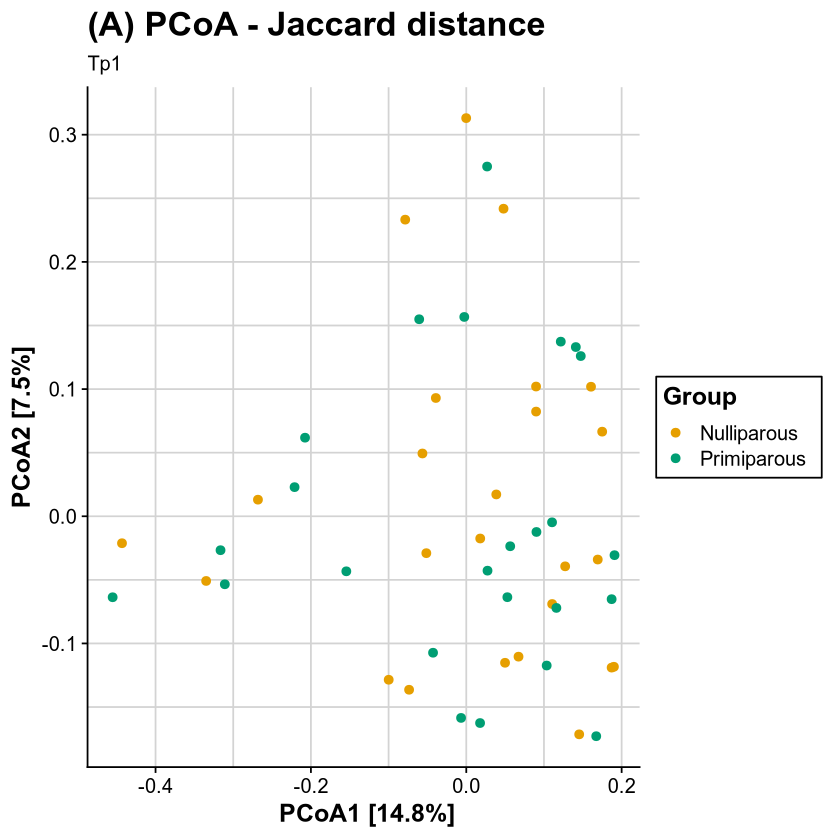

In [112]:
dye <- c("Nulliparous" = "#E69F00", "Primiparous" = "#009E73")

jaccard_plot <- jaccard_merged |>
    ggplot(aes(x = Dim1, y = Dim2, colour = Group)) +
    geom_point() +
    labs(
        y = paste0("PCoA2 [", jaccard_dim2, "%]"),
        x = paste0(" PCoA1 [", jaccard_dim1, "%]"),
        title = "(A) PCoA - Jaccard distance",
        subtitle = "Tp1"
    ) +
    scale_colour_manual(values = dye) +
    theme_half_open() +
    theme(
        legend.box.background = element_rect(color = "Black", size = 0.5),
        legend.box.margin = margin(4, 4, 4, 4),
        legend.title = element_text(face = "bold", size = 15),
        title = element_text(size = 18),
         axis.title.y = element_text(size = 15, face = "bold"),
        axis.title.x = element_text(size = 15, face = "bold"),
        panel.grid.major = element_line(colour = "lightgrey"),
        panel.grid.minor = element_line(colour = "lightgrey")
)
jaccard_plot

## PERMANOVA----------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [65]:
set.seed(123)
adonis_Group <- adonis2(formula = jaccard ~ Group, na.action = na.omit, data = adonis_tab)
# adonis_Group
# Rename "Model" to say Group, for better orientation
rownames(adonis_Group)[1] <- "Group"
adonis_Group
jaccard_pval <- adonis_Group[1, "Pr(>F)"]
jaccard_pval

jaccard_r2 <- adonis_Group[1, "R2"]
jaccard_r2

,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Group,1,0.07974016,0.008587952,0.4157925,1
Residual,48,9.20537872,0.991412048,NA,NA
Total,49,9.28511888,1.000000000,NA,NA


[1] 1

[1] 0.008587952

In [66]:
adonis_Age <- adonis2(formula = jaccard ~ Age , na.action = na.omit, data = adonis_tab)
# Rename "Model" for better orientation
rownames(adonis_Age)[1] <- "Age"
adonis_Age

,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Age,1,0.2267892,0.02442501,1.201754,0.186
Residual,48,9.0583297,0.97557499,NA,NA
Total,49,9.2851189,1.00000000,NA,NA


In [67]:
set.seed(123)

adonis_bmigroups <- adonis2(formula = jaccard ~ BMI_groups, na.action = na.omit, data = adonis_tab)
# Rename "Model" for better orientation
rownames(adonis_bmigroups)[1] <- "BMI_groups"
adonis_bmigroups

,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
BMI_groups,2,0.5465836,0.0665045,1.46047,0.015
Residual,41,7.6721630,0.9334955,NA,NA
Total,43,8.2187466,1.0000000,NA,NA


In [68]:
adonis_group_bmi <- adonis2(formula = jaccard ~ Group + BMI_prior, na.action = na.omit, data = adonis_tab)
# Rename "Model" for better orientation
rownames(adonis_group_bmi)[1] <- "Group_BMI"
adonis_group_bmi

,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Group_BMI,2,0.3465979,0.03732832,0.9112301,0.677
Residual,47,8.9385210,0.96267168,NA,NA
Total,49,9.2851189,1.00000000,NA,NA


# Aitchison=========================================================================================================

## Robust Aitchison

In [69]:
aitchison <- ordered_taxa |>
   as.matrix() |>
    vegdist(method = "robust.aitchison")
head(aitchison)
head(as.matrix(aitchison))

[1]  9.532443 14.838708 19.615486 17.133448 14.039372  8.995063

,1,2,3,4,5,6,7,8,9,10,⋯,41,42,43,44,45,46,47,48,49,50
1,0.000000,9.532443,14.838708,19.615486,17.13345,14.03937,8.995063,24.339568,14.289565,18.331111,⋯,34.06628,21.478042,20.402688,11.700833,13.36400,5.100919,13.626389,21.27799,18.26904,8.925416
2,9.532443,0.000000,19.798456,23.649602,12.31095,19.33853,10.396176,29.128082,6.588995,15.024178,⋯,39.76700,26.550957,27.408630,6.497901,16.72852,10.700731,15.086805,26.26227,23.05669,15.288036
3,14.838708,19.798456,0.000000,8.462212,30.80493,11.97046,18.809856,15.315529,23.883338,31.561360,⋯,36.65431,7.483873,13.509682,16.596269,11.12566,10.686921,6.967428,23.43451,27.25507,15.541288
4,19.615486,23.649602,8.462212,0.000000,35.18217,20.38875,25.589754,7.713057,25.747478,37.105500,⋯,44.53126,12.156641,20.623201,18.950324,19.32652,14.728056,12.087292,31.73437,34.61651,22.953872
5,17.133448,12.310953,30.804934,35.182175,0.00000,27.08530,14.984530,39.925786,13.361812,5.907118,⋯,40.22013,37.240265,35.299286,18.565408,25.54542,20.914456,26.843320,29.44029,21.94575,20.762966
6,14.039372,19.338527,11.970455,20.388749,27.08530,0.00000,12.232847,26.706107,25.519846,25.593292,⋯,25.70531,13.665056,9.144565,19.691633,4.27347,13.741953,12.675803,11.66397,17.34110,7.641950


In [70]:
# Convert to matrix and re-assign proper row and column names since they did not transfer properly
aitchison_matrix <- as.matrix(aitchison)
rownames(aitchison_matrix) <- rownames(ordered_taxa)
colnames(aitchison_matrix) <- rownames(ordered_taxa)
head(aitchison_matrix)

,100000128343,100000158999,100000101469,100000103241,100000141564,100000157404,100000108109,100000101155,100000148624,100000114162,⋯,100000193464,100000410189,100000417447,100000401859,100000422410,100000429136,100000424421,100000165058,100000401705,100000180006
100000128343,0.000000,9.532443,14.838708,19.615486,17.13345,14.03937,8.995063,24.339568,14.289565,18.331111,⋯,34.06628,21.478042,20.402688,11.700833,13.36400,5.100919,13.626389,21.27799,18.26904,8.925416
100000158999,9.532443,0.000000,19.798456,23.649602,12.31095,19.33853,10.396176,29.128082,6.588995,15.024178,⋯,39.76700,26.550957,27.408630,6.497901,16.72852,10.700731,15.086805,26.26227,23.05669,15.288036
100000101469,14.838708,19.798456,0.000000,8.462212,30.80493,11.97046,18.809856,15.315529,23.883338,31.561360,⋯,36.65431,7.483873,13.509682,16.596269,11.12566,10.686921,6.967428,23.43451,27.25507,15.541288
100000103241,19.615486,23.649602,8.462212,0.000000,35.18217,20.38875,25.589754,7.713057,25.747478,37.105500,⋯,44.53126,12.156641,20.623201,18.950324,19.32652,14.728056,12.087292,31.73437,34.61651,22.953872
100000141564,17.133448,12.310953,30.804934,35.182175,0.00000,27.08530,14.984530,39.925786,13.361812,5.907118,⋯,40.22013,37.240265,35.299286,18.565408,25.54542,20.914456,26.843320,29.44029,21.94575,20.762966
100000157404,14.039372,19.338527,11.970455,20.388749,27.08530,0.00000,12.232847,26.706107,25.519846,25.593292,⋯,25.70531,13.665056,9.144565,19.691633,4.27347,13.741953,12.675803,11.66397,17.34110,7.641950


In [71]:
aitchison_pcoa <- wcmdscale(aitchison_matrix, eig = TRUE)
aitchison_points <- data.frame(aitchison_pcoa$points)
head(aitchison_points)
aitchison_merged <- aitchison_points |>
  rownames_to_column(var = "Sample_ID") |>
  left_join(adonis_tab, by = "Sample_ID")
head(aitchison_merged)

,Dim1,Dim2,Dim3
,<dbl>,<dbl>,<dbl>
100000128343,-4.485908,-2.214533,3.7950250
100000158999,-10.034065,-7.103666,-2.2201074
100000101469,9.422225,-3.585906,-1.1919988
100000103241,13.032350,-10.741796,1.5226435
100000141564,-21.318803,-3.179685,0.7491763
100000157404,3.569799,6.568899,-3.6252755


,Sample_ID,Dim1,Dim2,Dim3,Group,Studynumber,Personalnumber,Age,Age_groups,excess_weight,Weight_before_C,BMI_prior,Primipara,Smoking,Alcohol,Antibiotics,High_stress,BMI_groups
,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<int>,<int>,<fct>,<int>,<int>,<int>,<fct>,<fct>,<fct>,<fct>,<fct>
1,100000128343,-4.485908,-2.214533,3.7950250,Nulliparous,S194e21b,P159f9c8,36,4,Yes,60,21,1,0,0,0,0,NA
2,100000158999,-10.034065,-7.103666,-2.2201074,Nulliparous,S1a267fa,P1a267fa,32,3,No,55,21,1,0,0,0,0,18.5-25 Normal weight
3,100000101469,9.422225,-3.585906,-1.1919988,Nulliparous,Sa8397fa,P1ef420d,27,2,No,67,25,1,0,0,0,0,NA
4,100000103241,13.032350,-10.741796,1.5226435,Nulliparous,S1f862a6,P1f862a6,32,3,Yes,67,25,1,0,0,0,0,> 25 Overweight
5,100000141564,-21.318803,-3.179685,0.7491763,Nulliparous,S3c0f6ee,P3c0f6ee,31,3,No,97,36,1,0,0,1,1,> 25 Overweight
6,100000157404,3.569799,6.568899,-3.6252755,Nulliparous,S2b86cc0,P3cac7b0,31,3,No,56,21,1,0,0,0,1,18.5-25 Normal weight


In [72]:
head(aitchison_pcoa)

,Dim1,Dim2,Dim3
100000128343,-4.4859080,-2.21453335,3.79502505
100000158999,-10.0340649,-7.10366554,-2.22010743
100000101469,9.4222254,-3.58590642,-1.19199876
100000103241,13.0323496,-10.74179597,1.52264354
100000141564,-21.3188026,-3.17968515,0.74917627
100000157404,3.5697990,6.56889881,-3.62527546
100000108109,-8.1081326,3.10910283,-2.48586167
100000101155,16.5213518,-13.89096619,7.63826607
100000148624,-12.4936390,-13.07426714,-0.90966231
100000114162,-21.5535521,2.46207354,-0.98561478


In [73]:
nrow(ordered_taxa)
length(aitchison_pcoa$eig)
eig_vals <- aitchison_pcoa$eig
# How many non-zero eigenvalues?
sum(eig_vals > 1e-6)  # Threshold to count "non-zero" dimensions

# Show all eigenvalues
eig_vals

[1] 50

[1] 3

[1] 3

[1] 6638.535 5836.939  623.704

In [74]:
# Save the eigenvalues, add percentages for plot
aitchison_dim1 <- round(aitchison_pcoa$eig[1]/sum(aitchison_pcoa$eig)*100, digits = 1)
aitchison_dim2 <- round(aitchison_pcoa$eig[2]/sum(aitchison_pcoa$eig)*100,  digits = 1)
aitchison_dim1
aitchison_dim2

[1] 50.7

[1] 44.6

In [75]:
aitchison_dim3 <- round(aitchison_pcoa$eig[3]/sum(aitchison_pcoa$eig)*100, digits = 1)
aitchison_dim4 <- round(aitchison_pcoa$eig[4]/sum(aitchison_pcoa$eig)*100,  digits = 1)
aitchison_dim3
aitchison_dim4

[1] 4.8

[1] NA

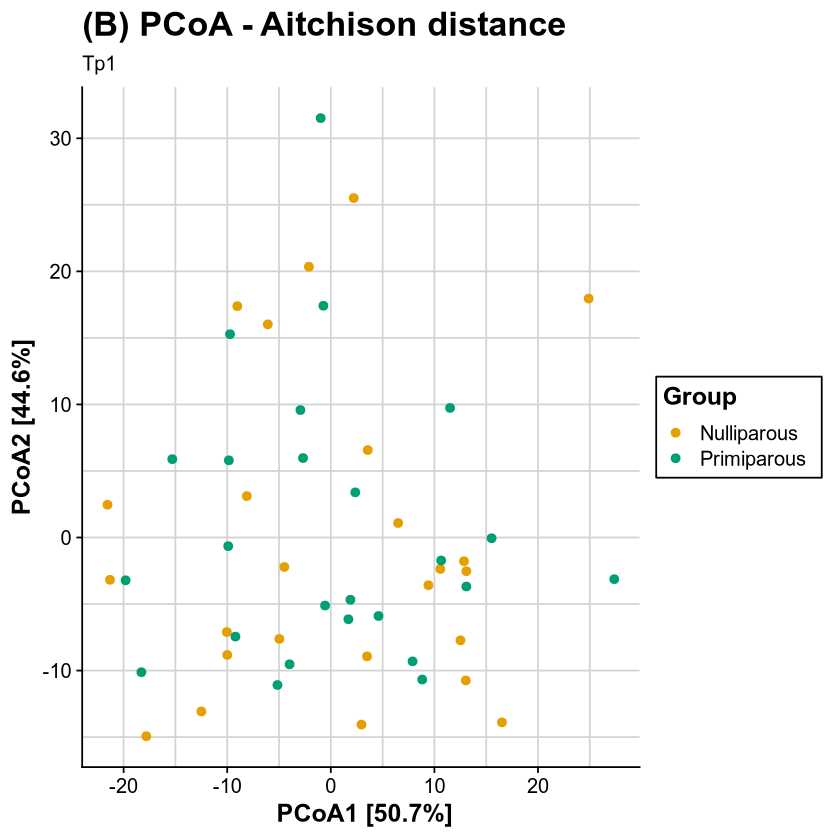

In [76]:
aitchison_plot <- aitchison_merged |>
    ggplot(aes(x = Dim1, y = Dim2, colour = Group)) +
    geom_point() +
    labs(
        y = paste0("PCoA2 [", aitchison_dim2, "%]"),
        x = paste0(" PCoA1 [", aitchison_dim1, "%]"),
        title = "(B) PCoA - Aitchison distance",
        subtitle = "Tp1"
    ) +
    scale_colour_manual(values = dye) +
    theme_half_open() +
    #background_grid() +
    theme(
        legend.box.background = element_rect(color="Black", size=0.5),
        legend.box.margin = margin(4, 4, 4, 4),
        legend.title = element_text(face = "bold", size = 15),
        title = element_text(size = 18),
        axis.title.y = element_text(size = 15, face = "bold"),
        axis.title.x = element_text(size = 15, face = "bold"),
        panel.grid.major = element_line(colour = "lightgrey"),
        panel.grid.minor = element_line(colour = "lightgrey")
)
    
aitchison_plot

## PERMANOVA----------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [77]:
set.seed(123)
adonis_ait_Group <- adonis2(formula = aitchison  ~ Group, na.action = na.omit, data = adonis_tab)
rownames(adonis_ait_Group)[1] <- "Group"
adonis_ait_Group
aitchison_pval <- adonis_ait_Group[1, "Pr(>F)"]
aitchison_pval

aitchison_r2 <- adonis_ait_Group[1, "R2"]
aitchison_r2

,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Group,1,13.08434,0.0009988672,0.04799356,0.977
Residual,48,13086.09356,0.9990011328,NA,NA
Total,49,13099.17790,1.0000000000,NA,NA


[1] 0.977

[1] 0.0009988672

In [78]:
adonis_ait_Age <- adonis2(formula = aitchison  ~ Age, na.action = na.omit, data = adonis_tab)
rownames(adonis_ait_Age)[1] <- "Age"
adonis_ait_Age

,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Age,1,285.0692,0.02176237,1.067832,0.38
Residual,48,12814.1087,0.97823763,NA,NA
Total,49,13099.1779,1.00000000,NA,NA


In [79]:
set.seed(123)
adonis_ait_bmigroups <- adonis2(formula = aitchison ~ BMI_groups, na.action = na.omit, data = adonis_tab)
rownames(adonis_ait_bmigroups)[1] <- "BMI_groups"
adonis_ait_bmigroups

,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
BMI_groups,2,216.2202,0.01824324,0.3809359,0.849
Residual,41,11635.8546,0.98175676,NA,NA
Total,43,11852.0748,1.00000000,NA,NA


In [80]:
set.seed(123)
adonis_ait_group_bmigroups <- adonis2(formula = aitchison ~ Group + BMI_groups, na.action = na.omit, data = adonis_tab)
rownames(adonis_ait_group_bmigroups)[1] <- "Group_bmi_groups"
adonis_ait_group_bmigroups

,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Group_bmi_groups,3,232.8219,0.01964398,0.267168,0.961
Residual,40,11619.2529,0.98035602,NA,NA
Total,43,11852.0748,1.00000000,NA,NA


# Bray curtis=======================================================================================================================================

In [81]:
bray_curt_dist <- vegdist(ordered_taxa, method = "bray")
head(as.matrix(bray_curt_dist))

,100000128343,100000158999,100000101469,100000103241,100000141564,100000157404,100000108109,100000101155,100000148624,100000114162,⋯,100000193464,100000410189,100000417447,100000401859,100000422410,100000429136,100000424421,100000165058,100000401705,100000180006
100000128343,0.0000000,0.7420494,0.6228461,0.6668333,0.6248962,0.7105762,0.6895960,0.8286332,0.6697165,0.7027625,⋯,0.6903054,0.7062986,0.7545467,0.5773035,0.6155732,0.6594316,0.6592115,0.6950226,0.7944307,0.7677458
100000158999,0.7420494,0.0000000,0.6361781,0.7507035,0.5905869,0.5736707,0.5820191,0.7668123,0.6364212,0.5122788,⋯,0.6432977,0.6317062,0.6982153,0.5875784,0.6204552,0.6045534,0.5798649,0.6055667,0.6453173,0.5682435
100000101469,0.6228461,0.6361781,0.0000000,0.5628025,0.6147230,0.6576598,0.6078307,0.7640252,0.6242098,0.6958694,⋯,0.6582506,0.5995227,0.7022631,0.6167714,0.6258210,0.5926844,0.5751818,0.6814968,0.7644823,0.7054185
100000103241,0.6668333,0.7507035,0.5628025,0.0000000,0.6588450,0.6685681,0.6587283,0.7005912,0.6145138,0.7232896,⋯,0.6715691,0.5903884,0.7111435,0.6124596,0.6270184,0.5848612,0.6404994,0.7265436,0.7272966,0.7433893
100000141564,0.6248962,0.5905869,0.6147230,0.6588450,0.0000000,0.6490930,0.5843837,0.7867992,0.5862270,0.5543725,⋯,0.6586917,0.6028236,0.6964542,0.5714720,0.6019359,0.5867833,0.6178479,0.6347017,0.7080824,0.6697056
100000157404,0.7105762,0.5736707,0.6576598,0.6685681,0.6490930,0.0000000,0.6333691,0.7865809,0.6240304,0.4922607,⋯,0.6391521,0.5779251,0.7096211,0.6350775,0.5717896,0.6223856,0.5439408,0.6067099,0.5715393,0.6778951


In [82]:
bray_curt_pcoa <- pco(bray_curt_dist)
#head(bray_curt_pcoa)

In [83]:
bray_vect <- bray_curt_pcoa$vectors
bray_curt_merged <- bray_vect |>
    rownames_to_column(var= "Sample_ID") |>
    left_join(adonis_tab, by = "Sample_ID")
head(bray_curt_merged)

,Sample_ID,X1,X2,X3,X4,X5,X6,X7,X8,X9,⋯,Age_groups,excess_weight,Weight_before_C,BMI_prior,Primipara,Smoking,Alcohol,Antibiotics,High_stress,BMI_groups
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<int>,<fct>,<int>,<int>,<int>,<fct>,<fct>,<fct>,<fct>,<fct>
1,100000128343,0.11816263,0.23860921,-0.121801225,0.01822817,0.20343093,0.004276005,-0.02335950,-0.08150602,0.033102079,⋯,4,Yes,60,21,1,0,0,0,0,NA
2,100000158999,-0.15397106,0.09840774,0.099380914,-0.14336000,-0.18414812,-0.137528343,-0.05042553,0.01179888,-0.022823587,⋯,3,No,55,21,1,0,0,0,0,18.5-25 Normal weight
3,100000101469,0.16285717,0.09102754,-0.008449862,0.02784154,-0.01158490,-0.046943799,-0.22389111,-0.03327800,0.064510601,⋯,2,No,67,25,1,0,0,0,0,NA
4,100000103241,0.22032648,0.02743598,-0.132983146,0.01118636,0.06592769,0.071654899,-0.18568609,-0.02270179,0.011591352,⋯,3,Yes,67,25,1,0,0,0,0,> 25 Overweight
5,100000141564,-0.01169167,0.24725043,-0.110277883,0.09440979,-0.05937729,-0.050468605,0.12245766,0.08008029,0.041273995,⋯,3,No,97,36,1,0,0,1,1,> 25 Overweight
6,100000157404,-0.11516322,-0.02934096,-0.006853645,-0.16585210,-0.04146478,0.173594523,-0.01203156,-0.09846845,0.005093587,⋯,3,No,56,21,1,0,0,0,1,18.5-25 Normal weight


In [84]:
bray_curt_df <- data.frame(Sample_ID = bray_curt_merged[,1],
                          Group = bray_curt_merged$Group,
                           pcoa1 = bray_curt_merged[,2],
                           pcoa2 = bray_curt_merged[,3],
                           pcoa3 = bray_curt_merged[,4]
                          )
head(bray_curt_df)

,Sample_ID,Group,pcoa1,pcoa2,pcoa3
,<chr>,<chr>,<dbl>,<dbl>,<dbl>
1,100000128343,Nulliparous,0.11816263,0.23860921,-0.121801225
2,100000158999,Nulliparous,-0.15397106,0.09840774,0.099380914
3,100000101469,Nulliparous,0.16285717,0.09102754,-0.008449862
4,100000103241,Nulliparous,0.22032648,0.02743598,-0.132983146
5,100000141564,Nulliparous,-0.01169167,0.24725043,-0.110277883
6,100000157404,Nulliparous,-0.11516322,-0.02934096,-0.006853645


In [85]:
# Save the eigenvalues, add percentages for plot
bray_dim1 <- round(bray_curt_pcoa$values[1]/sum(bray_curt_pcoa$values)*100, digits = 1)
bray_dim2 <- round(bray_curt_pcoa$values[2]/sum(bray_curt_pcoa$values)*100,  digits = 1)
bray_dim2
bray_dim1

[1] 9.2

[1] 12.2

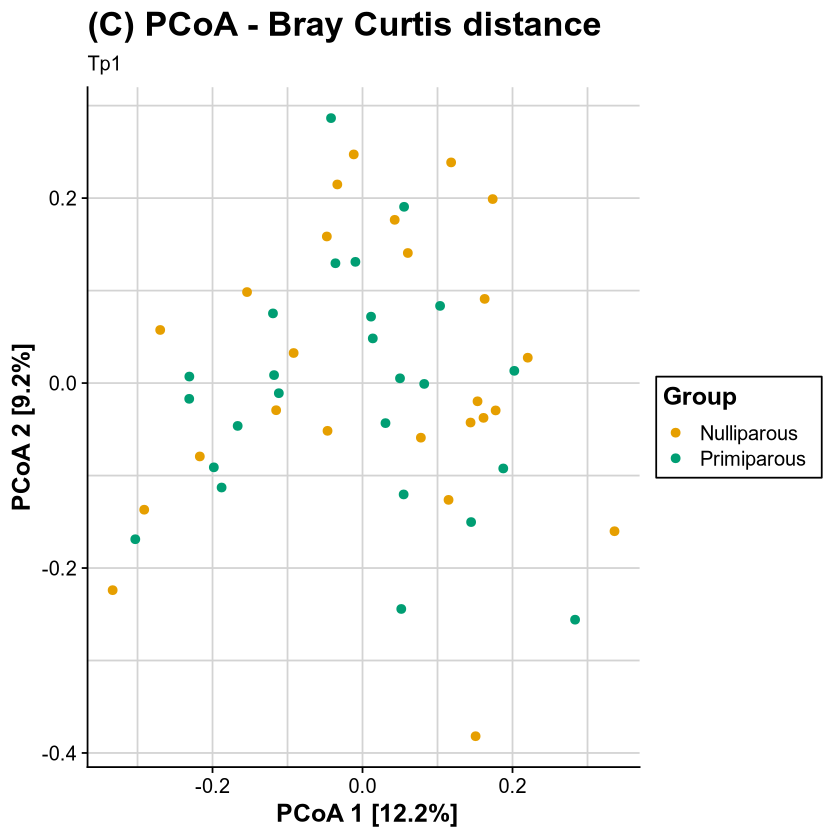

In [86]:
bray_plot <- bray_curt_df |>
    ggplot(aes(x = pcoa1, y = pcoa2, color = Group)) +
    geom_point() +
    labs(
        x = paste0(" PCoA 1 [", bray_dim1, "%]"),
        y = paste0("PCoA 2 [", bray_dim2, "%]"),
        title = "(C) PCoA - Bray Curtis distance",
        subtitle = "Tp1"
    ) +
    scale_color_manual(values = dye) +
    theme_half_open() +
    theme( 
        legend.box.background = element_rect(color="Black", size=0.5),
        legend.box.margin = margin(4, 4, 4, 4),
        legend.title = element_text(face = "bold", size = 15),
        title = element_text(size = 18),
        axis.title.y = element_text(size = 15, face = "bold"),
        axis.title.x = element_text(size = 15, face = "bold"),
        panel.grid.major = element_line(colour = "lightgrey"),
        panel.grid.minor = element_line(colour = "lightgrey")
     )

bray_plot

## PERMANOVA----------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [87]:
set.seed(123)
adonis_bray_Group <- adonis2(formula = bray_curt_dist ~ Group, na.action = na.omit, data = adonis_tab)
rownames(adonis_bray_Group)[1] <- "Group"
adonis_bray_Group
bray_pval <- adonis_bray_Group[1,"Pr(>F)"]
bray_pval

bray_r2 <- adonis_bray_Group[1, "R2"]
bray_r2

,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Group,1,0.1299875,0.01228607,0.5970668,0.987
Residual,48,10.4500884,0.98771393,NA,NA
Total,49,10.5800759,1.00000000,NA,NA


[1] 0.987

[1] 0.01228607

In [88]:
adonis_bray_Age <- adonis2(formula = bray_curt_dist ~ Age, na.action = na.omit, data = adonis_tab)
rownames(adonis_bray_Age)[1] <- "Age"
adonis_bray_Age
#head(adonis_tab)

,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Age,1,0.2755358,0.02604289,1.283485,0.122
Residual,48,10.3045401,0.97395711,NA,NA
Total,49,10.5800759,1.00000000,NA,NA


In [89]:
set.seed(123)
adonis_bray_bmigroups <- adonis2(formula = bray_curt_dist ~ BMI_groups, na.action = na.omit, data = adonis_tab)
rownames(adonis_bray_bmigroups)[1] <- "BMI_groups"
adonis_bray_bmigroups

,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
BMI_groups,2,0.5961628,0.06485079,1.421635,0.017
Residual,41,8.5966750,0.93514921,NA,NA
Total,43,9.1928378,1.00000000,NA,NA


# Exporting data===============================================================================

In [90]:
#write.csv(jaccard_merged, file = paste0("/ceph/projects/010_SweMaMi/bm.nowak/filtered_data/tp1_nulliparous/tp1_alpha_beta_diversity/beta/", Sys.Date(), 
                              #          "_jaccard_merged_tp1", ".csv"), row.names = FALSE)

#write.csv(aitchison_merged, file = paste0("/ceph/projects/010_SweMaMi/bm.nowak/filtered_data/tp1_nulliparous/tp1_alpha_beta_diversity/beta/", Sys.Date(), 
                              #          "_aitchison_merged_tp1", ".csv"), row.names = FALSE)

#write.csv(bray_curt_merged, file = paste0("/ceph/projects/010_SweMaMi/bm.nowak/filtered_data/tp1_nulliparous/tp1_alpha_beta_diversity/beta/", Sys.Date(), 
 #                                       "_bray_curt_df_tp1", ".csv"), row.names = FALSE)

# Combined plot --------------------------------------------------------------------------

In [100]:
# Extract legend from bray plot
legend_bray <- get_legend(bray_plot)

In [103]:
# remove legends so only one remains
plot_jaccard_nl <- jaccard_plot +  guides(fill = "none", color = "none") 
plot_aitch_nl <- aitchison_plot +  guides(fill = "none", color = "none") 
plot_bray_nl <- bray_plot +  guides(fill = "none", color = "none") 

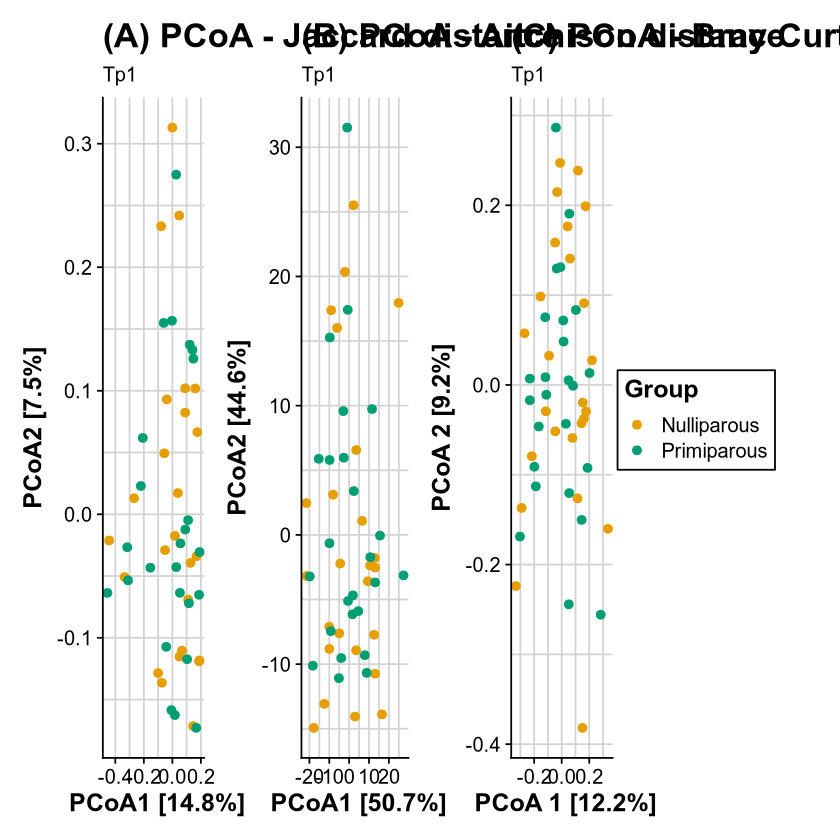

In [106]:

combined_plot <- plot_grid(plot_jaccard_nl, plot_aitch_nl, plot_bray_nl, nrow =1) 

combined_plot_legend <- plot_grid(plot_jaccard_nl, plot_aitch_nl, plot_bray_nl, legend_bray, nrow =1) 

final_plot <- ggdraw(combined_plot_legend) +
  theme_half_open() +
  background_grid() +
  theme(
    axis.text.x = element_blank(),
    plot.title = element_text(size = 15),
    axis.title = element_text(size = 15)
  )
final_plot


In [108]:
ggsave(file = paste0(Sys.Date(), "_gut_beta_tp1.pdf"), path ="/ceph/projects/010_SweMaMi/bm.nowak/plot_output/", 
      plot = final_plot, width = 19, height = 8)

# Bar plots --------------------------------------------------------------------------------------

In [94]:
bar_df <- data.frame(
    Distance_metrics = c("Jaccard", "Aitchison", "Bray Curtis"),
    Pvalue = c(jaccard_pval, aitchison_pval, bray_pval),
    R2 = c(jaccard_r2, aitchison_r2, bray_r2)
)
bar_df

Distance_metrics,Pvalue,R2
<chr>,<dbl>,<dbl>
Jaccard,1.000,0.0085879522
Aitchison,0.977,0.0009988672
Bray Curtis,0.987,0.0122860661


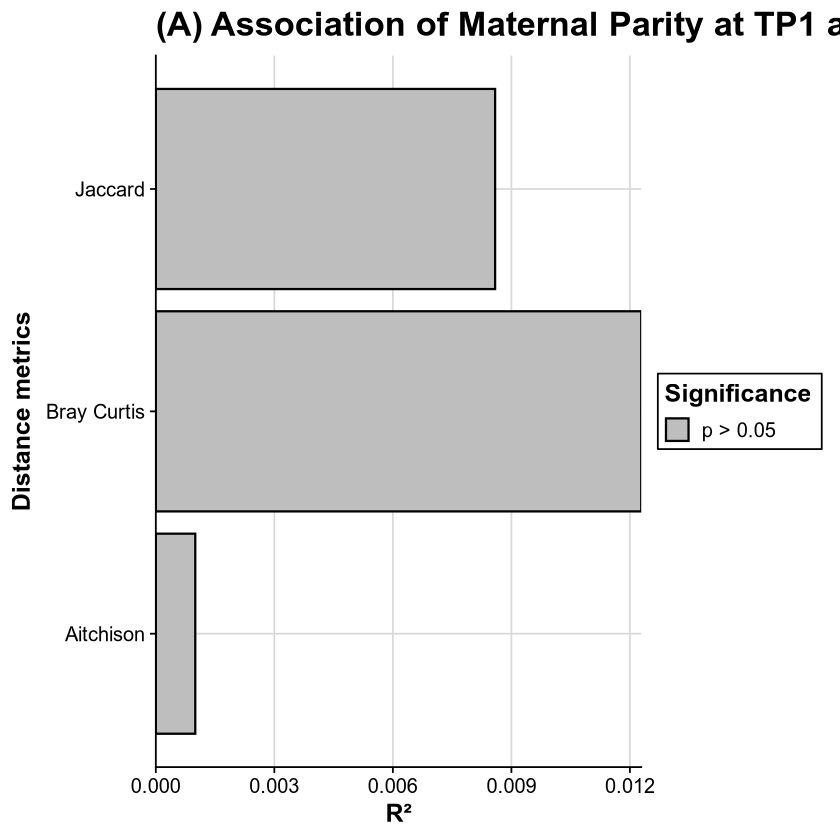

In [98]:
# Create column specifying p value greater or lesser
bar_df$Significance <- factor(ifelse(bar_df$Pvalue < 0.05, "p ≤ 0.05", "p > 0.05"))
dye_pval <- c("p ≤ 0.05" = "#0072B2", "p > 0.05" = "grey") # color vector 

#names(dye_pval) <- bar_df$Distance

bar_plot <- bar_df |>
    ggplot(aes(x = R2, y = Distance_metrics, fill = Significance)) +
    geom_col(colour = "black") +
    scale_fill_manual(values = dye_pval) +
    scale_x_continuous(expand = c(0, 0)) +   # removes gap
    labs(title = "(A) Association of Maternal Parity at TP1 across Distance Metrics for the Gut Microbiome",
        x = "R²",
        y = "Distance metrics") +
    theme_half_open() +
    theme(
        legend.box.background = element_rect(color="Black", size=0.5),
        legend.box.margin = margin(4, 4, 4, 4),
        legend.title = element_text(face = "bold", size = 15),
        title = element_text(size = 18),
        axis.title.y = element_text(size = 15, face = "bold"),
        axis.title.x = element_text(size = 15, face = "bold"),
        panel.grid.major = element_line(colour = "lightgrey"),
        panel.grid.minor = element_line(colour = "lightgrey")) +
    background_grid()

bar_plot

In [99]:
ggsave(file = paste0(Sys.Date(), "_gut_beta_tp1_bar.pdf"), path ="/ceph/projects/010_SweMaMi/bm.nowak/plot_output/", 
       plot = bar_plot, width = 14, height = 8)